# Zeit-bis-Studienabbruch-Überlebensanalyse einer Studierendenkohorte

## Zusammenfassung

**Ausgangslage.** Ein Referat für institutionelle Forschung an einem vierjährigen College möchte verstehen, *wann* und nicht nur *ob* Studierende das Studium verlassen. Eine Erstimmatrikulationskohorte wird ab der Einschreibung Semester für Semester verfolgt; einige schließen ab, einige brechen ab, und einige sind noch eingeschrieben, wenn das Beobachtungsfenster schließt. Da das Ergebnis für noch eingeschriebene Studierende unbekannt ist (rechtszensiert) und da ein Abschluss eine Person aus der Risikogruppe entfernt, ohne ein Abbruch zu sein, verwirft eine gewöhnliche Bestehen/Nichtbestehen-Regression die Zeitinformation und verzerrt jede Schätzung, die die Zensierung ignoriert. Das richtige Werkzeug ist die **Ereigniszeit- bzw. Überlebensanalyse (time-to-event / survival analysis)**, bei der das interessierende Ereignis der **Studienabbruch** ist und die Uhr in eingeschriebenen akademischen Semestern gemessen wird.

**Fragestellung.** Trennt der **akademische Status im ersten Semester** einer Person (ein Frühwarn-Indikator) die Abbruchzeit-Verläufe der Kohorte, und welche Merkmale der Studierenden treiben nach Adjustierung das Abbruchrisiko (Hazard)? Die Antworten fließen in ein Frühwarnsystem: Studierende mit hohem geschätztem Abbruchrisiko sollten in ihren ersten Semestern eine beratende Ansprache erhalten, wenn die Intervention am günstigsten und wirksamsten ist.

**Vorgehen.** Wir simulieren eine Kohorte von 100 Studierenden inline (keine externen Daten) und durchlaufen dann einen üblichen Überlebensanalyse-Workflow:

1. **PROC MEANS** profiliert die Prädiktoren über die drei beobachteten Ergebnisse (Abgeschlossen / Abgebrochen / noch Eingeschrieben), um zu bestätigen, dass sich das simulierte Signal sinnvoll verhält.
2. **PROC FREQ** kreuztabelliert den akademischen Status im ersten Semester gegen das Ergebnis mit einem Chi-Quadrat-Test auf Assoziation.
3. **PROC UNIVARIATE** berichtet robuste Perzentile der Zeit-bis-Abbruch nach Status.
4. **PROC LIFETEST** schätzt Kaplan-Meier-Abbruchkurven, stratifiziert nach Status, und führt **Log-Rank**- und **Wilcoxon**-Tests auf Gleichheit durch.
5. **PROC PHREG** passt ein multivariables **Cox-Proportional-Hazards**-Modell für das Abbruchrisiko an, mit einem referenzkodierten `CLASS`-Effekt, Efron-Behandlung von Bindungen und Konfidenzintervallen der Risikogrenzen.

**Was die Daten zeigen.** Von den 100 simulierten Studierenden haben **49 abgebrochen, 49 abgeschlossen und 2 blieben eingeschrieben** zum Stichtag nach 12 Semestern. Studierende, die im ersten Semester wegen **akademischer Warnung** markiert wurden (Erstsemester-GPA unter 2,5), brechen weit schneller ab als Studierende mit gutem Stand: mediane Zeit-bis-Abbruch **3,8 Semester gegenüber 8,7 Semestern**, eine Trennung, die der Log-Rank-Test bestätigt (Chi-Quadrat = 10,73, *p* = 0,0011). Das Cox-Modell identifiziert den Erstsemester-GPA (Hazard Ratio 0,21 pro GPA-Punkt, *p* < 0,0001), den High-School-GPA (HR 0,45, *p* = 0,027) und den Status als Studierende der ersten Generation (HR 2,03, *p* = 0,031) als signifikante adjustierte Treiber des Abbruchs, während der Pell-Stipendien-Status nach Kontrolle des GPA nicht signifikant ist (HR 0,95, *p* = 0,85).

> *Alle Zahlen sind illustrativ und aus synthetischen Daten erzeugt; es handelt sich nicht um echte Studierendendaten. Diese Umgebung läuft ohne Lizenz, daher ist die Kohorte auf 100 Studierende dimensioniert.*

## Datenquellen

Alle Daten sind **synthetisch**, inline im ersten DATA-Step mit `CALL STREAMINIT(20260611)` und der Funktion `RAND` erzeugt. Keine externen Dateien oder Netzwerkzugriffe. Eine Zeile pro simulierter Person.

**Datensatz `einschreibungen`** (100 Zeilen, eine Zeile pro Person)

| Variable | Typ | Beschreibung | Erzeugende Verteilung |
|----------|------|-------------|--------------------------|
| `studenten_id` | Num | Eindeutiger Studierendenschlüssel | Folge 1–100 |
| `erste_gen` / `erste_gen_txt` | Num / Char | Kennzeichen erste Generation (0/1) und Label | Bernoulli, ~42 % |
| `pell` | Num | Kennzeichen Pell-Stipendium (finanzieller Bedarf) (0/1) | Bernoulli, ~42 % |
| `studiengang` | Char | MINT / WIWI / GEIS | kategorial (~42 % / 32 % / 26 %) |
| `schul_note` | Num | High-School-GPA (1,8–4,0) | Normal(3,00, 0,42), begrenzt |
| `semester1_note` | Num | College-GPA im ersten Semester (0–4,0) | f(hs_gpa, program) + normalverteiltes Rauschen |
| `status` | Char | Akademischer Status im ersten Semester | `semester1_note < 2.5` → Akademische Warnung, sonst Guter Stand |
| `zeit_semester` | Num | Eingeschriebene Semester bis Ereignis oder Zensierung | konkurrierende Weibull-Ziehungen; bei 12 gedeckelt |
| `abgebrochen` | Num | Indikator für Abbruchereignis (1 = abgebrochen, 0 = zensiert) | abgeleitet |
| `ergebnis` | Char | Abgeschlossen / Abgebrochen / Eingeschrieben | aus konkurrierenden Ziehungen abgeleitet |

Ein latenter linearer Prädiktor auf der Log-Skala verknüpft die **Abbruchrate** jeder Person mit dem Erstsemester-GPA, dem High-School-GPA, dem Status der ersten Generation und dem finanziellen Bedarf, sodass die Prädiktoren ein echtes, aber verrauschtes Signal tragen. Abbruch und Abschluss werden als **konkurrierende** latente Zeiten (Weibull) gezogen; was zuerst innerhalb eines 12-Semester-Fensters eintritt, wird zum beobachteten Ergebnis, und Studierende, die Semester 12 ohne beides erreichen, werden rechtszensiert. Für die Überlebensmodelle ist das **Ereignis der Abbruch** (`abgebrochen = 1`); Abschluss und laufende Einschreibung werden beide als Zensierung behandelt (`dropped = 0`).

## 1. Die Studierendenkohorte simulieren

Die erste Zelle erstellt eine synthetische Kohorte von 100 Studierenden. Ein latenter linearer Prädiktor auf der Log-Skala verbindet die Abbruchrate jeder Person mit dem Erstsemester-GPA, dem High-School-GPA, dem Status der ersten Generation und dem Pell-Status. Abbruch und Abschluss werden als **konkurrierende** latente Zeiten erzeugt (Weibull-Ziehungen); was zuerst innerhalb eines 12-Semester-Beobachtungsfensters eintritt, wird zum beobachteten Ergebnis, und Studierende, die Semester 12 ohne Abbruch oder Abschluss erreichen, werden rechtszensiert. Ein Erstsemester-GPA unter 2,5 markiert die Person für eine **akademische Warnung** — das Frühwarnsignal, das wir im Überlebensschritt testen. Die Zufallsziehungen verwenden `CALL STREAMINIT` zur Reproduzierbarkeit und die Funktion `RAND` über Gleich-, Normal- und Weibull-Verteilungen. Harte Untergrenzen und Begrenzungen halten jeden Wert plausibel (GPAs in 0–4,0).

In [1]:
DATEN einschreibungen;
    AUFRUFEN streaminit(20260611);
    LÄNGE status $24 erste_gen_txt $20 studiengang $4 ergebnis $16;
    BEZEICHNUNG studenten_id   = "Studenten-ID"
          erste_gen      = "Erste-Generation-Kennzeichen"
          erste_gen_txt  = "Erste-Generation-Status"
          pell           = "Pell-Förderung"
          studiengang    = "Studiengang"
          schul_note     = "Schulnote (GPA)"
          semester1_note = "Note 1. Semester (GPA)"
          status         = "Akademischer Status"
          zeit_semester  = "Zeit bis Ereignis (Semester)"
          abgebrochen    = "Abbruch-Kennzeichen"
          ergebnis       = "Ergebnis";
    AUSFÜHRUNG studenten_id = 1 BIS 100;
        /* Kennzeichen erste Generation und finanzieller Bedarf */
        erste_gen = (rand("uniform") < 0.42);
        WENN erste_gen DANN erste_gen_txt = "Erste Generation";
        SONST              erste_gen_txt = "Folgegeneration";
        pell = (rand("uniform") < 0.42);

        /* Studiengang */
        v = rand("uniform");
        WENN      v < 0.42 DANN studiengang = "MINT";
        SONST WENN v < 0.74 DANN studiengang = "WIWI";
        SONST                  studiengang = "GEIS";

        /* Akademische Vorbereitung und Leistung im 1. Semester */
        schul_note = round(MIN(4.0, MAX(1.8, rand("normal", 3.00, 0.42))), 0.01);
        semester1_note = round(MIN(4.0, MAX(0.0,
                     0.55*schul_note + 1.05 + 0.12*(studiengang="MINT")
                     + rand("normal", 0, 0.42))), 0.01);

        /* Fruehwarn-Kennzeichen: GPA 1. Semester unter 2,5 = Warnung */
        WENN semester1_note < 2.5 DANN status = "Akademische Warnung";
        SONST                        status = "Guter Stand";

        /* Latente Abbruch-Hazard auf Log-Skala: niedrigerer GPA,
           erste Generation und Pell-Status erhoehen die Rate. */
        eta = -1.05
             - 1.45*(semester1_note - 2.8)
             - 0.55*(schul_note - 3.0)
             + 1.05*erste_gen
             + 0.45*pell;
        abbruch_rate = EXP(eta);

        /* Konkurrierende latente Zeiten (Semester): Abbruch vs Abschluss */
        t_abbruch = rand("weibull", 1.2, 7.0) / MAX(0.30, abbruch_rate);
        t_abschluss = rand("weibull", 2.0, 7.5)
                 * EXP(-0.18*(semester1_note - 2.8));

        /* 12-Semester administratives Zensierungsfenster */
        zensur_bei = 12;
        WENN t_abbruch <= t_abschluss UND t_abbruch <= zensur_bei DANN AUSFÜHRUNG;
            ergebnis = "Abgebrochen";    abgebrochen = 1; zeit_semester = t_abbruch;
        ENDE;
        SONST WENN t_abschluss < t_abbruch UND t_abschluss <= zensur_bei DANN AUSFÜHRUNG;
            ergebnis = "Abgeschlossen";  abgebrochen = 0; zeit_semester = t_abschluss;
        ENDE;
        SONST AUSFÜHRUNG;
            ergebnis = "Eingeschrieben"; abgebrochen = 0; zeit_semester = zensur_bei;
        ENDE;
        zeit_semester = round(zeit_semester, 0.1);
        AUSGABE;
    ENDE;
    BEHALTEN studenten_id erste_gen erste_gen_txt pell studiengang schul_note
         semester1_note status zeit_semester abgebrochen ergebnis;
AUSFÜHREN;


NOTE: DATA einschreibungen


NOTE: Wrote einschreibungen (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


## 2. Prädiktoren nach beobachtetem Ergebnis profilieren

Vor der Modellierung bestätigen wir, dass sich die simulierten Prädiktoren in die erwarteten Richtungen bewegen. **PROC MEANS** berichtet Anzahl, Mittelwert, Streuung und Spannweite jedes numerischen Prädiktors innerhalb der drei beobachteten Ergebnisse.

Die Kohorte teilt sich in **49 Abgeschlossen / 49 Abgebrochen / 2 noch Eingeschrieben**. Absolventinnen und Absolventen weisen einen höheren Erstsemester-GPA auf (Mittelwert **2,94** gegenüber **2,54** bei Abbrechenden) und einen höheren High-School-GPA (**3,10** gegenüber **2,90**) — genau das Gefälle der akademischen Vorbereitung, das die Analyse erwartet. Die beiden noch eingeschriebenen Studierenden liegen bei `zeit_semester` genau an der 12-Semester-Zensierungsgrenze (Mittelwert 12,00, Standardabweichung 0), der Rechtszensierung, die eine Abbruchanalyse respektieren muss. Bei Abbrechenden tritt das Ereignis früh ein: Mittelwert **3,31 Semester**, im Bereich von 0,1 bis 8,9.

In [2]:
PROZEDUR MITTELWERTE DATEN=einschreibungen n mean std MIN MAX maxdec=2;
    KLASSE ergebnis;
    VAR schul_note semester1_note zeit_semester;
AUSFÜHREN;

                                                  The MEANS Procedure

                                     Analysis Variable : schul_note Schulnote (GPA)

        Ergebnis                N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------------
        Abgebrochen                49           2.90           0.45           2.01           3.89
        Abgeschlossen              49           3.10           0.46           1.97           4.00
        Eingeschrieben              2           3.10           0.17           2.98           3.22
        -----------------------------------------------------------------------------------------

                               Analysis Variable : semester1_note Note 1. Semester (GPA)

        Ergebnis                N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 3. Verfolgt der Frühwarn-Indikator das Ergebnis?

Das Frühwarnsystem markiert jede Person, deren Erstsemester-GPA unter 2,5 fällt, für eine **akademische Warnung**. **PROC FREQ** kreuztabelliert diesen Indikator gegen das beobachtete Ergebnis und führt einen Chi-Quadrat-Test auf Assoziation durch. Wir unterdrücken Zeilen-, Spalten- und Gesamtprozente (`NOROW NOCOL NOPERCENT`), damit die Tabelle die reinen Häufigkeiten zeigt, und fügen einwertige Häufigkeiten von `status` und dem Status der ersten Generation für die Zusammensetzung der Kohorte hinzu.

Die Kreuztabelle ist deutlich: Von den **29** wegen akademischer Warnung markierten Studierenden haben **21 abgebrochen** und nur 8 abgeschlossen; von den **71** mit gutem Stand haben **41 abgeschlossen** und 28 abgebrochen. Die Assoziation ist signifikant (Chi-Quadrat = 9,21, df = 2, *p* = 0,0100; Cramérs V = 0,30). Man beachte die **damit ausgegebene Warnung**: Bei 100 Studierenden und einer dünnen „Eingeschrieben“-Spalte mit nur zwei Absolventinnen und Absolventen hat ein Drittel der Tabellenzellen erwartete Häufigkeiten unter 5, sodass der Chi-Quadrat-*p*-Wert hier fragil ist. Genau diese Fragilität ist der Grund, warum die Überlebenstests in den nächsten Abschnitten — die die vollständige Zeitinformation statt einer 3×2-Tabelle nutzen — der vertrauenswürdigere Test des Status-Effekts sind.

                                                   The FREQ Procedure

Table of Akademischer Status by Ergebnis

Akademischer Status |   Abgebrochen | Abgeschlossen |Eingeschrieben |          Total
--------------------+---------------+---------------+---------------+---------------
Akademische Warnung |            21 |             8 |             0 |             29
--------------------+---------------+---------------+---------------+---------------
Guter Stand         |            28 |            41 |             2 |             71
--------------------+---------------+---------------+---------------+---------------
Total               |            49 |            49 |             2 |            100

Statistics for Table of Akademischer Status by Ergebnis

Statistic                                DF  Value         Prob
--------------------------------------------------------------
Chi-Square                                2 9.2089       0.0100
Likelihood Ratio Chi-Square               2


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_status_ergebnis.spec.json
NOTE: ODS plot written: freq_status.spec.json
NOTE: ODS plot written: freq_erste_gen_txt.spec.json
NOTE: PROC FREQ statement used.


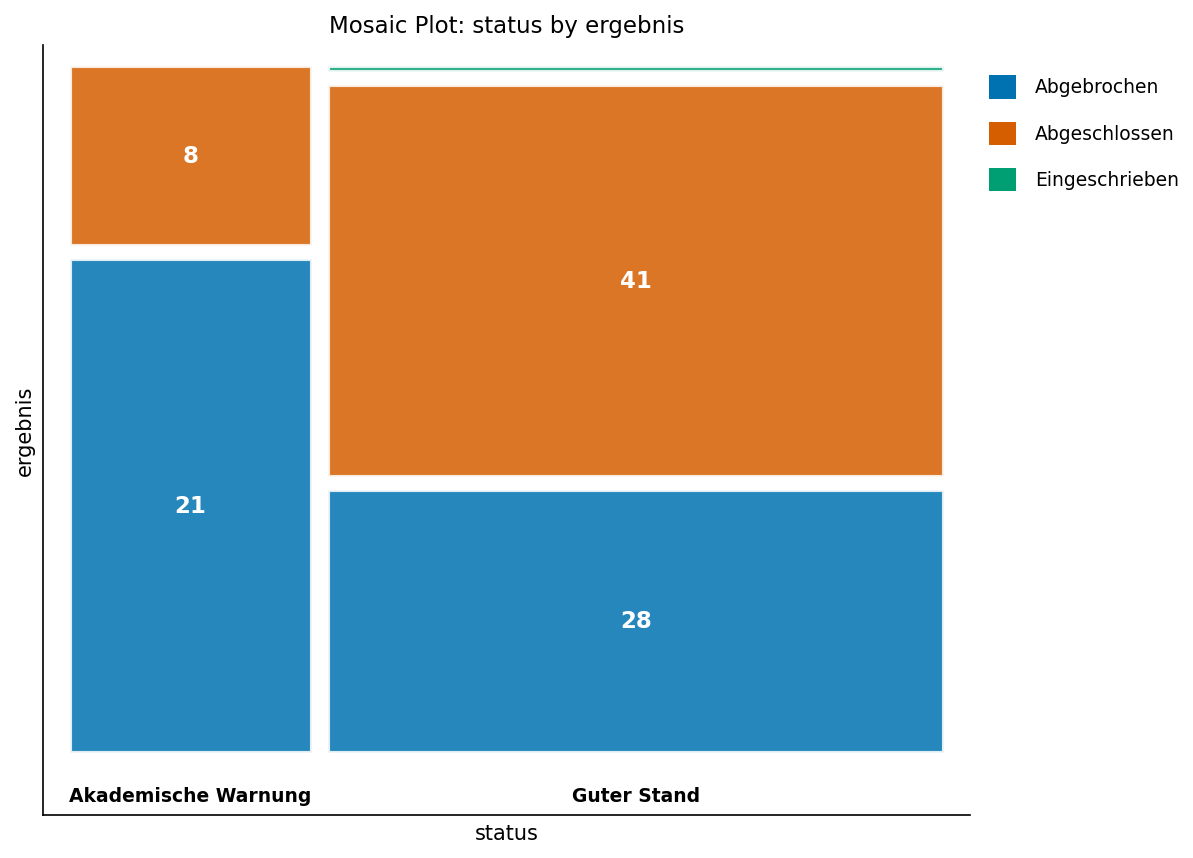

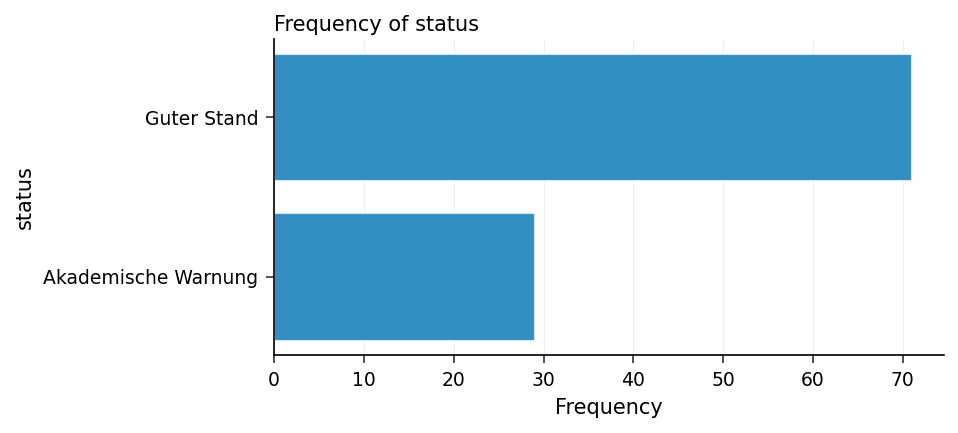

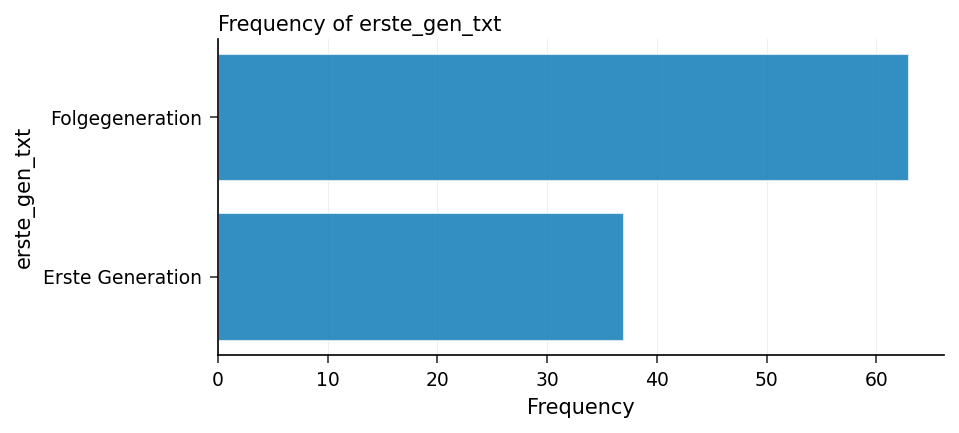

In [3]:
PROZEDUR HÄUFIGKEITEN DATEN=einschreibungen;
    TABLES status*ergebnis / chisq norow nocol nopercent;
    TABLES status erste_gen_txt;
AUSFÜHREN;

## 4. Wann treten Abbrüche auf? Perzentile nach Status

Für die Studierenden, die tatsächlich abgebrochen haben: *wann* sind sie gegangen? **PROC UNIVARIATE** (beschränkt auf `abgebrochen = 1`) berichtet das 10., 50. (Median) und 90. Perzentil der Zeit-bis-Abbruch innerhalb jeder Statusgruppe, geschrieben in einen Ausgabedatensatz, den wir anschließend ausgeben. Dies beschreibt die Streuung der Abbruchzeit, ohne eine Verteilung anzunehmen.

Der mediane Abbruch unter den Ausscheidenden erfolgt um Semester **2,4** (akademische Warnung) gegenüber **2,6** (guter Stand) — nahe beieinander, weil *bedingt auf einen Abbruch* beide Gruppen tendenziell früh gehen. Der Status-Effekt betrifft daher nicht in erster Linie den *Zeitpunkt* eines Abbruchs, sondern *wie viele* Studierende abbrechen und wie schnell die Risikogruppe ausdünnt — genau das, was die Kaplan-Meier-Kurven im nächsten Abschnitt erfassen.

In [4]:
PROZEDUR UNIVARIATE DATEN=einschreibungen NOPRINT;
    WO abgebrochen = 1;
    KLASSE status;
    VAR zeit_semester;
    AUSGABE out=abbruch_perzentile pctlpts=10 50 90 pctlpre=t_ p=;
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=abbruch_perzentile noobs BEZEICHNUNG;
    TITEL "Perzentile der Zeit bis zum Abbruch (Semester), nach akademischem Status";
AUSFÜHREN;
TITEL;

                        Perzentile der Zeit bis zum Abbruch (Semester), nach akademischem Status                        

             STATUS  T_10  T_50  T_90
Akademische Warnung   0.2   2.4   7.9
Guter Stand           0.4   2.6   8.7




NOTE: PROC UNIVARIATE
NOTE: Output dataset abbruch_perzentile has 2 observations and 4 variables.
NOTE: PROC PRINT data=abbruch_perzentile

NOTE: PROC PRINT completed: 2 observations printed, 4 variables


## 5. Kaplan-Meier-Abbruchkurven nach akademischem Status

Nun der Kern des Überlebensschritts. **PROC LIFETEST** schätzt die nichtparametrische **Kaplan-Meier**-Überlebensfunktion für die *Zeit bis zum Abbruch* und behandelt Abschluss und laufende Einschreibung als Zensierung (`abgebrochen(0)` kennzeichnet die zensierten Beobachtungen). Die Stratifizierung nach `status` erzeugt eine Abbruchkurve pro Gruppe, und `TEST=(LOGRANK WILCOXON)` führt zwei komplementäre Tests durch, ob sich diese Kurven unterscheiden: Der **Log-Rank**-Test gewichtet alle Ereigniszeiten gleich (empfindlich für späte Unterschiede), während der **Wilcoxon**-Test frühe Ereigniszeiten stärker gewichtet (empfindlich für frühen Schwund). `PLOTS=SURVIVAL` fordert die überlagerte Überlebenskurven-Grafik an.

In der gesamten Kohorte gibt es **49 Abbruchereignisse und 51 zensierte** Beobachtungen. Die Kurven trennen sich klar: Studierende mit akademischer Warnung erreichen eine **mediane Überlebenszeit (Zeit-bis-Abbruch) von 3,8 Semestern**, während Studierende mit gutem Stand mehr als doppelt so lange durchhalten (**8,7 Semester**). Beide Tests verwerfen die Gleichheit — **Log-Rank-Chi-Quadrat = 10,73, *p* = 0,0011; Wilcoxon-Chi-Quadrat = 7,66, *p* = 0,0056** — und die vergleichbaren Statistiken sagen uns, dass die Lücke über das gesamte Einschreibungsfenster hinweg bestehen bleibt und nicht nur ein früher Ausschlag ist. Die Grafik macht die Botschaft unmittelbar: Die orange Kurve der akademischen Warnung fällt in den ersten vier Semestern steil ab, während die blaue Kurve des guten Stands hoch bleibt.

    The LIFETEST Procedure    

                             N
--------------------  --------
Total                      100
Event                       49
Censored                    51
Median Survival Time    3.8500

Stratum: Akademischer Status = Akademische Warnung

                             N
--------------------  --------
Total                       29
Event                       21
Censored                     8
Median Survival Time    3.8000

               Product-Limit Survival Estimates                

    Time  Survival  Std Error  Number at Risk  Number of Events
--------  --------  ---------  --------------  ----------------
  0.1000    0.9310     0.0471              29                 2
  0.2000    0.8966     0.0566              27                 1
  0.3000    0.8621     0.0640              26                 1
  1.2000    0.8276     0.0701              25                 1
  1.5000    0.7916     0.0758              23                 1
  1.6000    0.7556     0.0804


NOTE: PROC LIFETEST data=einschreibungen

NOTE: Using Python lifelines version 0.30.3
NOTE: ODS plot written: survival_strata.spec.json
NOTE: PROC LIFETEST completed.


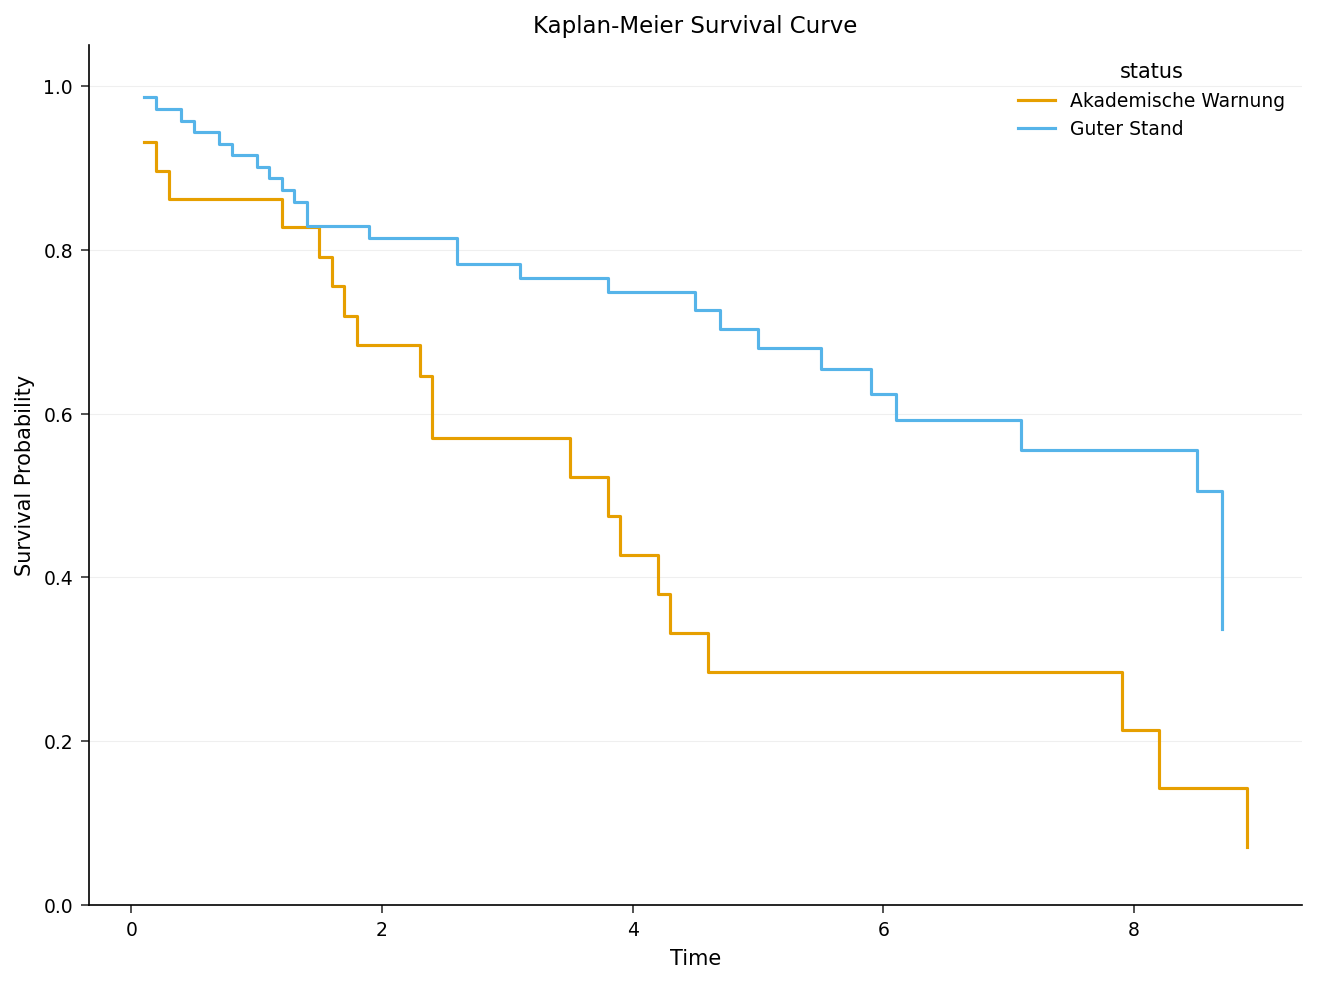

In [5]:
PROZEDUR LIFETEST DATEN=einschreibungen PLOTS=SURVIVAL METHOD=km;
    TIME zeit_semester*abgebrochen(0);
    STRATA status / TEST=(logrank WILCOXON);
AUSFÜHREN;

## 6. Multivariables Cox-Proportional-Hazards-Modell für den Abbruch

**PROC PHREG** passt das **Cox-Proportional-Hazards**-Modell für das Abbruchrisiko an und adjustiert die Prädiktoren simultan. Wichtige Anforderungen:

- `abgebrochen(0)` macht den **Abbruch** zum Ereignis und alles andere zur Zensierung.
- `KLASSE erste_gen_txt (ref="Folgegeneration") / param=ref` referenzkodiert den Faktor der ersten Generation, sodass seine Hazard Ratio gegen Studierende der fortführenden Generation gelesen wird.
- `TIES=EFRON` ist die empfohlene Näherung zur Behandlung von Bindungen, wenn mehrere Studierende im selben Semester ausscheiden.
- `RL` fügt Konfidenzintervalle der Hazard Ratio (Risikogrenzen) hinzu.
- Die Anweisung `HAZARDRATIO` berichtet den Kontrast der ersten Generation gegen die Referenzgruppe.

Eine Hazard Ratio über 1 bedeutet *schnelleren* Abbruch (höheres Risiko); unter 1 bedeutet *langsameren* Abbruch (schützend).

In [6]:
PROZEDUR PHREG DATEN=einschreibungen;
    KLASSE erste_gen_txt (REF="Folgegeneration") / PARAM=REF;
    MODELL zeit_semester*abgebrochen(0) = schul_note semester1_note erste_gen_txt pell
          / TIES=efron rl;
    hazardratio "Erste Generation vs. Folgegeneration" erste_gen_txt / DIFF=REF;
AUSFÜHREN;

        The PHREG Procedure        

Criterion                     Value
----------------------  -----------
Number of Observations          100
Number of Events                 49
-2 LOG L                    352.536
Ties Handling                 efron
Convergence Status      0 Converged

      Testing Global Null Hypothesis: BETA=0      

Test              Chi-Square        DF  Pr > ChiSq
----------------  ----------  --------  ----------
Likelihood Ratio     31.1053         4      <.0001
Wald                 29.9969         4      <.0001
Score (Log-Rank)     31.2100         4      <.0001

                                              Analysis of Maximum Likelihood Estimates                                              

Parameter                             DF  Estimate  Standard Error  Chi-Square  Pr > ChiSq  Hazard Ratio  95% Lower CL  95% Upper CL
------------------------------  --------  --------  --------------  ----------  ----------  ------------  ------------  ------------
SC


NOTE: PROC PHREG data=einschreibungen

NOTE: PROC PHREG spec written to: ./ods_output/phreg_basic.spec.json
NOTE: PROC PHREG using Python wrapper


## 7. Interpretation und nächste Schritte

**Die Ausgabe von Anfang bis Ende lesen:**

- **PROC MEANS** bestätigt das simulierte Signal: Studierende, die abgeschlossen haben, weisen einen höheren Erstsemester-GPA (2,94 gegenüber 2,54) und High-School-GPA (3,10 gegenüber 2,90) auf als Abbrechende, und die noch eingeschriebenen Studierenden liegen an der 12-Semester-Grenze — der Rechtszensierung, die die Überlebensmodelle respektieren.
- **PROC FREQ** zeigt, dass der Indikator für die akademische Warnung im ersten Semester das Ergebnis verfolgt (21 von 29 markierten Studierenden brachen ab; 41 von 71 Studierenden mit gutem Stand schlossen ab; *p* = 0,0100), weist dabei aber ehrlich darauf hin, dass das Chi-Quadrat in einer 100-Studierenden-Tabelle mit dünn besetzten Zellen fragil ist.
- **PROC UNIVARIATE** zeigt, dass *bedingt auf einen Abbruch* beide Gruppen früh gehen (Median ~2,4–2,6 Semester); der Status-Effekt betrifft, wie viele Studierende abbrechen und wie schnell die Risikogruppe ausdünnt, nicht den Zeitpunkt unter den Ausscheidenden.
- **PROC LIFETEST** liefert die Schlagzeile: Kaplan-Meier-Abbruchkurven, die sich nach Status scharf trennen (Median 3,8 gegenüber 8,7 Semestern; Log-Rank-*p* = 0,0011, Wilcoxon-*p* = 0,0056). Der Frühwarn-Indikator ist ein echter, statistisch gestützter Diskriminator der Abbruchzeit.
- **PROC PHREG** quantifiziert den adjustierten Effekt jedes Prädiktors auf das Abbruchrisiko. Nach Adjustierung ist der **Erstsemester-GPA der stärkste Schutzfaktor** (Hazard Ratio 0,21 pro GPA-Punkt, 95 %-KI 0,10–0,44, *p* < 0,0001): Jeder zusätzliche GPA-Punkt senkt das Abbruchrisiko um etwa vier Fünftel. Der **High-School-GPA** ist ebenfalls schützend (HR 0,45, 95 %-KI 0,22–0,91, *p* = 0,027). **Studierende der ersten Generation** haben etwa das doppelte Abbruchrisiko von Peers der fortführenden Generation mit gleichem GPA (HR 2,03, 95 %-KI 1,07–3,84, *p* = 0,031). Der **Pell-Status ist nicht signifikant**, sobald der GPA kontrolliert wird (HR 0,95, 95 %-KI 0,53–1,69, *p* = 0,85) — eine nützliche Erinnerung daran, dass ein roher Risikofaktor nach Adjustierung verschwinden kann. Die globale Nullhypothese wird eindeutig verworfen (Likelihood-Ratio-Chi-Quadrat = 31,11 bei 4 df, *p* < 0,0001).

**Wie eine Institution darauf reagieren würde.** Das Cox-Modell erzeugt einen linearen Prädiktor pro Person (Risikoscore), der die Kohorte nach Abbruchrisiko sortiert; die Studierenden mit dem höchsten Risiko — niedriger Erstsemester-GPA kombiniert mit dem Status der ersten Generation — werden in ihren ersten Semestern der Frühwarn-Beratung zugeführt, wenn die Intervention am günstigsten und wirksamsten ist. Der Kaplan-Meier-Vergleich gibt Beratenden ein einziges, gut begründbares Kriterium, das sie ohnehin am Ende des ersten Semesters erheben: den akademischen Status.

**Einschränkungen und Erweiterungen.** (1) Diese synthetische Kohorte behandelt den Abschluss als Zensierung für das Abbruchmodell; bei echten Daten sind Abschluss und Abbruch echte **konkurrierende Risiken (competing risks)**, und eine Erweiterung um konkurrierende Risiken (kumulative Inzidenz) über PROC PHREG `EVENTCODE=` würde eine Überschätzung der Abbruchwahrscheinlichkeit vermeiden. (2) Die Proportional-Hazards-Annahme sollte geprüft werden (PHREG `ASSESS PH` oder Schoenfeld-Residuen), bevor man einer einzelnen Hazard Ratio über alle Semester hinweg vertraut. (3) Zeitveränderliche Kovariaten — semesterweiser GPA, Änderungen der finanziellen Förderung, Kursbelastung — sind in Retentionsdaten häufig und werden von PHREG-Programmieranweisungen natürlich behandelt. (4) Die hier verwendete 100-Studierenden-Kohorte ist auf das Limit des unlizenzierten Laufs dimensioniert; eine produktive Analyse würde mehrere tausend Studierende umfassen und jedes Konfidenzintervall verengen. Validieren Sie einen eingesetzten Risikoscore stets an einer zurückgehaltenen Kohorte, bevor Sie operativ danach handeln.